# 02 — TF-IDF baselines (NB / LR / SVM) on WELFake — Model Identification (MSE1)

**Fake News & Misinformation Detector** · MSE1 criterion *Model Identification* (master doc §12, MSE1 doc §3.5).

What this notebook shows

1. the processed WELFake parquet joined with the **saved split IDs** (`data/splits/welfake_{train,val}.csv`) — no re-splitting here; the **test split is not touched** (reserved for MSE2);
2. one TF-IDF matrix (word 1–2-grams, `sublinear_tf`, 100k features, lower-casing inside the vectoriser only) shared by **Multinomial NB, Logistic Regression and LinearSVC**; accuracy / precision / recall / **macro-F1** / confusion matrices on **val**;
3. the top-25 positive / negative LR coefficients and an explicit **leakage-token check** (Reuters, "featured image", pic.twitter, …);
4. a train-size sanity check (learning curve) and a quick ISOT-val run for comparison (+ a cross-dataset preview);
5. the saved artefact `data/models/tfidf_lr_welfake_v0.joblib` reloaded in one line and applied to three hand-written headlines;
6. the **model ladder** that these numbers justify (details: `docs/model_identification.md`).

All code lives in `src/models/baselines.py` (also the CLI behind `make train-baselines`). Runtime ≈ 3–5 min on the laptop CPU (budget ≤ 10 min).

In [1]:
import json, sys, platform, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from src import config as C
from src.models import baselines as B
import sklearn
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 160); pd.set_option("display.precision", 4)
C.FIGURES_DIR.mkdir(parents=True, exist_ok=True); C.MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("python", platform.python_version(), "| sklearn", sklearn.__version__, "| pandas", pd.__version__)
print("TF-IDF config:", {k: v for k, v in B.TFIDF_DEFAULTS.items() if k != "dtype"})
T0 = time.time()

python 3.11.11 | sklearn 1.9.0 | pandas 2.3.3
TF-IDF config: {'ngram_range': (1, 2), 'max_features': 100000, 'sublinear_tf': True, 'lowercase': True, 'min_df': 2, 'max_df': 0.95, 'strip_accents': 'unicode'}


## 1. Load the processed data and join the saved split IDs

`B.load_split(dataset, split)` reads `data/splits/{dataset}_{split}.csv` (`id,label`, written once by `make data`, seed 42) and joins it onto
`data/processed/{dataset}.parquet` by `id`; it raises if any id is missing or a label disagrees. The text stays **cased** on disk — lower-casing
happens inside `TfidfVectorizer`.

In [2]:
train = B.load_split("welfake", "train"); val = B.load_split("welfake", "val")
test_ids = pd.read_csv(C.SPLITS_DIR / "welfake_test.csv")           # only counted, never loaded as text
assert not set(train["id"]) & set(val["id"]) and not set(train["id"]) & set(test_ids["id"])
summary = pd.DataFrame({"rows": {"train": len(train), "val": len(val), "test (untouched)": len(test_ids)},
                        "real": {"train": (train.label == "real").sum(), "val": (val.label == "real").sum(), "test (untouched)": (test_ids.label == "real").sum()},
                        "fake": {"train": (train.label == "fake").sum(), "val": (val.label == "fake").sum(), "test (untouched)": (test_ids.label == "fake").sum()}})
summary["fake_frac"] = (summary["fake"] / summary["rows"]).round(4)
X_train_txt = B.make_input(train)
print("classifier input = title + '\\n' + text; median length", int(X_train_txt.str.len().median()), "chars; cased sample:", repr(X_train_txt.iloc[0][:90]))
summary

classifier input = title + '\n' + text; median length 2522 chars; cased sample: 'LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLi'


,rows,real,fake,fake_frac
train,48677,27436,21241,0.4364
val,6085,3430,2655,0.4363
test (untouched),6085,3430,2655,0.4363


## 2. TF-IDF + NB / LR / SVM on WELFake train → **val**

Configuration = one point of the master §12.2 grid (the full `GridSearchCV` is MSE2 work): word 1–2-grams, `sublinear_tf=True`,
`max_features=100 000`, `min_df=2`, `max_df=0.95`; NB `alpha=1`, LR `C=1` (liblinear), LinearSVC `C=1`.
The TF-IDF matrix is fitted **once** on train and shared by the three classifiers (master §12.3: "cache the TF-IDF matrix").

In [3]:
pipes, res, cache = B.fit_eval_all("welfake", B.MODEL_NAMES, train_df=train, eval_df=val)
rows = []
for m, r in res.items():
    rows.append({"model": B.MODEL_LABEL[m], "split": r.split, "accuracy": r.accuracy, "precision_macro": r.precision_macro,
                 "recall_macro": r.recall_macro, "macro_F1": r.f1_macro, "P_fake": r.precision_fake, "R_fake": r.recall_fake,
                 "train_s (tfidf+fit)": round(r.train_seconds, 1), "fit_s": round(r.fit_seconds, 2)})
metrics_welfake = pd.DataFrame(rows).set_index("model")
lr_f1 = res["lr"].f1_macro
print(f"\nMSE1 sanity bar: LR macro-F1 on WELFake val = {lr_f1:.4f} -> {'PASS (>= 0.90)' if lr_f1 >= 0.90 else 'FAIL (< 0.90)'}")
print(f"TF-IDF: {cache['X_train'].shape[1]:,} features, train matrix {cache['X_train'].shape[0]:,} x {cache['X_train'].shape[1]:,}, nnz {cache['X_train'].nnz:,}")
metrics_welfake

[welfake] tfidf fitted on 48,677 docs -> 100,000 features in 52.7s (nnz 24,679,063)


[welfake]  nb val: acc 0.8639  P 0.8613  R 0.8629  macro-F1 0.8620  fit 0.3s  cm [[2987, 443], [385, 2270]]


[welfake]  lr val: acc 0.9471  P 0.9463  R 0.9460  macro-F1 0.9462  fit 4.4s  cm [[3273, 157], [165, 2490]]


[welfake] svm val: acc 0.9615  P 0.9604  R 0.9615  macro-F1 0.9610  fit 1.8s  cm [[3298, 132], [102, 2553]]

MSE1 sanity bar: LR macro-F1 on WELFake val = 0.9462 -> PASS (>= 0.90)
TF-IDF: 100,000 features, train matrix 48,677 x 100,000, nnz 24,679,063


,split,accuracy,precision_macro,recall_macro,macro_F1,P_fake,R_fake,train_s (tfidf+fit),fit_s
model,,,,,,,,,
TF-IDF + Multinomial NB,val,0.8639,0.8613,0.8629,0.8620,0.8367,0.8550,53.0,0.25
TF-IDF + Logistic Regression,val,0.9471,0.9463,0.9460,0.9462,0.9407,0.9379,57.1,4.37
TF-IDF + LinearSVC,val,0.9615,0.9604,0.9615,0.9610,0.9508,0.9616,54.5,1.78


### 2.1 Confusion matrices on val (rows = true, columns = predicted; `fake` is the positive class)

saved /home/nikhil/Desktop/nlp/docs/figures/cm_lr_welfake_val.png and cm_baselines_welfake_val.png


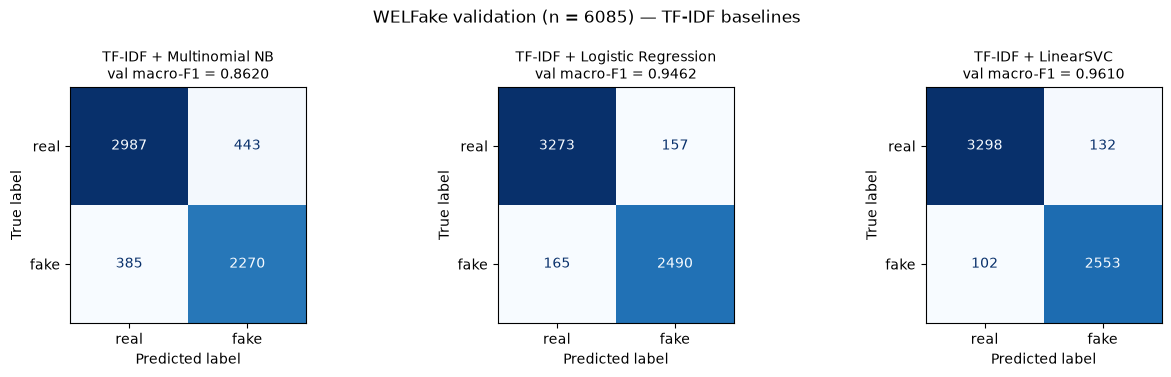

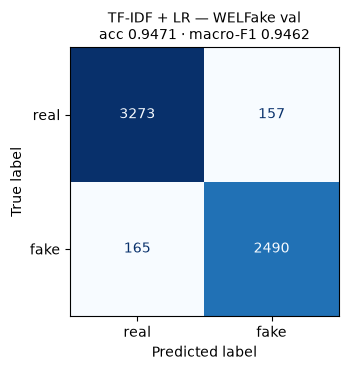

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, (m, r) in zip(axes, res.items()):
    ConfusionMatrixDisplay(np.asarray(r.confusion), display_labels=B.LABELS).plot(ax=ax, colorbar=False, values_format="d", cmap="Blues")
    ax.set_title(f"{B.MODEL_LABEL[m]}\nval macro-F1 = {r.f1_macro:.4f}", fontsize=10)
fig.suptitle("WELFake validation (n = %d) — TF-IDF baselines" % len(val)); fig.tight_layout()
fig.savefig(C.FIGURES_DIR / "cm_baselines_welfake_val.png", dpi=150, bbox_inches="tight")

fig, ax = plt.subplots(figsize=(4.2, 3.8))
ConfusionMatrixDisplay(np.asarray(res["lr"].confusion), display_labels=B.LABELS).plot(ax=ax, colorbar=False, values_format="d", cmap="Blues")
ax.set_title(f"TF-IDF + LR — WELFake val\nacc {res['lr'].accuracy:.4f} · macro-F1 {res['lr'].f1_macro:.4f}", fontsize=10)
fig.tight_layout(); fig.savefig(C.FIGURES_DIR / "cm_lr_welfake_val.png", dpi=150, bbox_inches="tight")
print("saved", C.FIGURES_DIR / "cm_lr_welfake_val.png", "and cm_baselines_welfake_val.png")
plt.show()

### 2.2 Top-25 LR coefficients (→ fake vs. → real) and the leakage-token check

If a source / boiler-plate token such as `reuters`, `featured image`, `getty`, `pic twitter`, `video`, `via` … ranks among the top coefficients,
the classifier is learning *where the text came from* rather than *what it says* — that is a **preprocessing gap** and is reported below, not hidden.

In [5]:
coef = B.top_coefficients(pipes["lr"], k=25)
leak_fake = B.find_leak_tokens(coef["fake_token"]); leak_real = B.find_leak_tokens(coef["real_token"])
print("LEAK CHECK (top-25 LR tokens vs. B.LEAK_TOKENS):")
print("  towards FAKE:", leak_fake if leak_fake else "none")
print("  towards REAL:", leak_real if leak_real else "none")
if leak_fake or leak_real:
    print("  -> PREPROCESSING GAP: these tokens survived artefact stripping (see the discussion cell below and agent-docs / eda_summary).")
else:
    print("  -> clean: no leakage tokens in the top-25 lists.")
# how often do the flagged tokens occur, per class, in the *training* text? (context for the discussion)
ctx = []
for t in (leak_fake + leak_real):
    pat = r"\b" + r"\s+".join(map(__import__("re").escape, t.split())) + r"\b"
    has = X_train_txt.str.contains(pat, case=False, regex=True)
    ctx.append({"token": t, "docs_fake": int((has & (train.label == 'fake')).sum()), "docs_real": int((has & (train.label == 'real')).sum()),
                "frac_fake": round(float(has[train.label == 'fake'].mean()), 4), "frac_real": round(float(has[train.label == 'real'].mean()), 4)})
leak_context = pd.DataFrame(ctx)
coef

LEAK CHECK (top-25 LR tokens vs. B.LEAK_TOKENS):
  towards FAKE: ['via', 'video', 'image']
  towards REAL: ['on twitter', 'twitter']
  -> PREPROCESSING GAP: these tokens survived artefact stripping (see the discussion cell below and agent-docs / eda_summary).


,rank,fake_token,fake_coef,real_token,real_coef
0,1,via,12.091,breitbart,-14.003
1,2,video,10.482,said,-13.342
2,3,2016,6.811,said on,-9.362
3,4,the us,6.131,president donald,-8.288
4,5,us,5.935,on twitter,-7.020
5,6,this,5.935,follow,-6.872
6,7,october,5.853,twitter,-6.458
7,8,hillary,5.740,on,-6.073
8,9,just,5.509,said in,-5.926
9,10,watch,5.427,york times,-5.640


In [6]:
print("Occurrence of the flagged tokens in the WELFake *train* text (per class):")
display(leak_context) if len(leak_context) else print("(nothing flagged)")
# a few example contexts for each flagged token, to see whether it is a residual artefact or ordinary prose
import re
for t in (leak_fake + leak_real)[:4]:
    pat = re.compile(r".{0,50}\b" + r"\s+".join(map(re.escape, t.split())) + r"\b.{0,50}", re.I | re.S)
    hits = [pat.search(x).group(0).replace("\n", " ") for x in X_train_txt[train.label == "fake"].head(4000) if pat.search(x)][:3]
    print(f"\n[{t}] e.g.:"); [print("   …", h, "…") for h in hits]

Occurrence of the flagged tokens in the WELFake *train* text (per class):


,token,docs_fake,docs_real,frac_fake,frac_real
0,via,3890,779,0.1831,0.0284
1,video,6752,1789,0.3179,0.0652
2,image,2150,804,0.1012,0.0293
3,on twitter,1412,3446,0.0665,0.1256
4,twitter,2860,4455,0.1346,0.1624



[via] e.g.:
   … would be nice to see, too.Photo: Chip Somodevilla via Getty images. …
   … lected items that might prove useful intelligence.Via: Vocativ.com …
   … f Hillary s event and posted a picture on Twitter:Via: The Federalist …



[video] e.g.:
   …  9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members …
   …  the Nation agreed that if the media could find a video of a puppy madly in love with balloons or somethi …
   … ese acts of violence. Source: Raw StoryHere s the video:Let s see if you can follow that logic and I ll b …



[image] e.g.:
   …  what America declares we do have: People are the image-bearers of God, created with dignity& inalienable …
   … ys, thanks in advance from the Democrats.Featured image: Flickr/Flickr …
   … nnects #AllLivesMatter And Zimmerman Gun Auction (IMAGE) At this point, the arguments against the #AllLiv …



[on twitter] e.g.:
   …  a thorough beatdown from Sen. Ben Sasse (R-Neb.) on Twitter during an epic tweetstorm. Richard Spencer, the A …
   … sident. He's Scary He taunts and threatens people on twitter. He hints at enemies lists. He says Saudi Arabia  …
   … s footage of Hillary s event and posted a picture on Twitter:Via: The Federalist …


**Reading the coefficients.** Politically loaded, sensational and second-person tokens (e.g. *hillary*, *you*, *breaking*, *video*, *just*) drive
predictions towards *fake*; wire-service register (*said on*, *washington*, *reuters*/*minister*, *percent*, dates) drives them towards *real*. This is a
**style / register** signal, not a truth signal — it is exactly why the classifier only adjusts confidence in the fusion (master §14) and why the
cross-dataset drop (§18) is expected. Tokens flagged above are recorded in `agent-docs/README.md` and `docs/model_identification.md` as a preprocessing follow-up.

## 3. Train-size sanity check (learning curve, LR)

Same fitted TF-IDF; LR refitted on random subsets of the train rows (seed 42). A curve that keeps rising means more data still helps; a flat curve
means the linear model has saturated (the transformer must then win on *representation*, not on data volume).

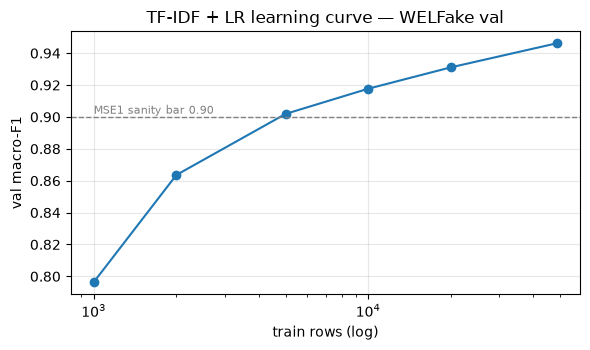

,n_train,val_macro_F1,val_acc,fit_s
0,1000,0.7964,0.8108,0.08
1,2000,0.8636,0.8680,0.14
2,5000,0.9019,0.9039,0.35
3,10000,0.9177,0.9191,0.73
4,20000,0.9311,0.9323,1.83
5,48677,0.9462,0.9471,25.70


In [7]:
rng = np.random.default_rng(C.SEED)
sizes = [1_000, 2_000, 5_000, 10_000, 20_000, cache["X_train"].shape[0]]
curve = []
for n in sizes:
    idx = np.sort(rng.choice(cache["X_train"].shape[0], size=n, replace=False)) if n < cache["X_train"].shape[0] else np.arange(n)
    clf = B.build_classifier("lr"); t0 = time.time(); clf.fit(cache["X_train"][idx], cache["y_train"][idx])
    m = B.compute_metrics(cache["y_eval"], clf.predict(cache["X_eval"]))
    curve.append({"n_train": n, "val_macro_F1": round(m["f1_macro"], 4), "val_acc": round(m["accuracy"], 4), "fit_s": round(time.time() - t0, 2)})
curve = pd.DataFrame(curve)
fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(curve["n_train"], curve["val_macro_F1"], marker="o"); ax.set_xscale("log"); ax.set_xlabel("train rows (log)"); ax.set_ylabel("val macro-F1")
ax.axhline(0.90, ls="--", c="grey", lw=1); ax.text(sizes[0], 0.902, "MSE1 sanity bar 0.90", fontsize=8, color="grey")
ax.set_title("TF-IDF + LR learning curve — WELFake val"); ax.grid(alpha=.3); fig.tight_layout()
fig.savefig(C.FIGURES_DIR / "train_lr_welfake_learning_curve.png", dpi=150, bbox_inches="tight"); plt.show()
curve

## 4. Save the LR pipeline → `data/models/tfidf_lr_welfake_v0.joblib` and reload in one line

The artefact is a self-contained sklearn `Pipeline(tfidf → clf)`: `joblib.load(path).predict([text])` is all a CPU-only teammate needs.

In [8]:
path = B.save_pipeline(pipes["lr"], C.MODELS_DIR / "tfidf_lr_welfake_v0.joblib")
print("saved", path, f"({path.stat().st_size / 2**20:.1f} MB)")
B.save_log(res["lr"].__class__(**{**res["lr"].__dict__, "artefact": str(path.relative_to(ROOT))}))   # JSON log for classifier_table.md
import joblib
clf = joblib.load(C.MODELS_DIR / "tfidf_lr_welfake_v0.joblib")            # <- the one-line reload
heads = B.demo_headlines()
proba = clf.predict_proba([h for _, h in heads]); fake_col = list(clf.classes_).index("fake")
pd.DataFrame({"intent": [i for i, _ in heads], "headline": [h for _, h in heads],
              "pred": clf.predict([h for _, h in heads]), "P(fake)": proba[:, fake_col].round(3)})

saved /home/nikhil/Desktop/nlp/data/models/tfidf_lr_welfake_v0.joblib (1.9 MB)


,intent,headline,pred,P(fake)
0,obviously fake,BREAKING: Scientists confirm the Moon is hollow and NASA has been hiding it ...,fake,0.904
1,plausibly real,"The central bank held its benchmark interest rate steady on Thursday, citing...",real,0.090
2,satire-ish,Local man declares himself emperor of his apartment complex after winning HO...,fake,0.727


> The headline predictions are a *feasibility* demo only: a 2-sentence input has almost no TF-IDF mass, and the model was trained on full
> articles (title + body). The web app will use the classifier the same way — as one confidence signal — never as the verdict (hard rule in `CLAUDE.md`).

## 5. Quick ISOT-val run for comparison (+ cross-dataset preview)

ISOT is the "leakage story" dataset (raw artefact-only accuracy ≈ 0.996, see `docs/mse1_make_data.log`). After artefact stripping the same three
baselines are fitted on ISOT train and scored on ISOT val. As a preview of MSE2's cross-dataset table, the **WELFake-trained** LR is also applied to
ISOT val without any adaptation (final cross-dataset numbers use the *test* splits at MSE2).

In [9]:
del cache; import gc; gc.collect()                    # free the WELFake matrices before the second TF-IDF fit
isot_train = B.load_split("isot", "train"); isot_val = B.load_split("isot", "val")
pipes_isot, res_isot, cache_isot = B.fit_eval_all("isot", B.MODEL_NAMES, train_df=isot_train, eval_df=isot_val)
for m, r in res_isot.items():
    B.save_log(r)
metrics_isot = pd.DataFrame([{"model": B.MODEL_LABEL[m], "dataset": "ISOT", "split": r.split, "accuracy": r.accuracy, "precision_macro": r.precision_macro,
                              "recall_macro": r.recall_macro, "macro_F1": r.f1_macro, "train_s (tfidf+fit)": round(r.train_seconds, 1)} for m, r in res_isot.items()]).set_index("model")
# cross-dataset preview: WELFake LR -> ISOT val (no retraining)
xm = B.compute_metrics(isot_val["label"], pipes["lr"].predict(B.make_input(isot_val)))
xm2 = B.compute_metrics(val["label"], pipes_isot["lr"].predict(B.make_input(val)))
cross = pd.DataFrame([{"train → eval": "WELFake → ISOT val", "accuracy": xm["accuracy"], "macro_F1": xm["f1_macro"], "confusion": xm["confusion"]},
                      {"train → eval": "ISOT → WELFake val", "accuracy": xm2["accuracy"], "macro_F1": xm2["f1_macro"], "confusion": xm2["confusion"]}])
print("In-domain ISOT val:"); display(metrics_isot)
print("Cross-dataset preview (LR, C=1, no adaptation):"); cross

[isot] tfidf fitted on 30,086 docs -> 100,000 features in 26.9s (nnz 12,354,945)
[isot]  nb val: acc 0.9577  P 0.9575  R 0.9569  macro-F1 0.9572  fit 0.1s  cm [[2017, 74], [85, 1585]]


[isot]  lr val: acc 0.9843  P 0.9843  R 0.9839  macro-F1 0.9841  fit 2.4s  cm [[2065, 26], [33, 1637]]


[isot] svm val: acc 0.9912  P 0.9913  R 0.9910  macro-F1 0.9911  fit 0.9s  cm [[2077, 14], [19, 1651]]


In-domain ISOT val:


,dataset,split,accuracy,precision_macro,recall_macro,macro_F1,train_s (tfidf+fit)
model,,,,,,,
TF-IDF + Multinomial NB,ISOT,val,0.9577,0.9575,0.9569,0.9572,27.1
TF-IDF + Logistic Regression,ISOT,val,0.9843,0.9843,0.9839,0.9841,29.3
TF-IDF + LinearSVC,ISOT,val,0.9912,0.9913,0.9910,0.9911,27.8


Cross-dataset preview (LR, C=1, no adaptation):


,train → eval,accuracy,macro_F1,confusion
0,WELFake → ISOT val,0.9854,0.9851,"[[2088, 3], [52, 1618]]"
1,ISOT → WELFake val,0.8274,0.8274,"[[2531, 899], [151, 2504]]"


### 5.1 Why WELFake → ISOT does *not* drop: ISOT is (almost entirely) contained in WELFake

WELFake was assembled from four sources — Kaggle, McIntire, **Reuters (= ISOT)** and BuzzFeed Political (Verma et al. 2021). A hash join on the
normalised processed text quantifies the overlap; this decides what "cross-dataset" can mean at MSE2.

In [10]:
import hashlib, re
norm = lambda s: re.sub(r"\W+", " ", s.lower()).strip()
h = lambda s: hashlib.sha1(norm(s).encode()).hexdigest()
w_all = pd.read_parquet(C.PROCESSED_DIR / "welfake.parquet", columns=["id", "text", "split"]); i_all = pd.read_parquet(C.PROCESSED_DIR / "isot.parquet", columns=["id", "text", "label", "split"])
w_all["h"] = w_all.text.map(h); i_all["h"] = i_all.text.map(h)
shared = set(w_all.h) & set(i_all.h); w_train_h = set(w_all[w_all.split == "train"].h)
overlap = pd.DataFrame([
    {"check": "ISOT rows whose text also occurs in WELFake", "n": int(i_all.h.isin(shared).sum()), "of": len(i_all)},
    {"check": "WELFake rows involved", "n": int(w_all.h.isin(shared).sum()), "of": len(w_all)},
    {"check": "ISOT val rows present in WELFake TRAIN", "n": int(i_all[i_all.split == "val"].h.isin(w_train_h).sum()), "of": int((i_all.split == "val").sum())},
    {"check": "ISOT test rows present in WELFake TRAIN", "n": int(i_all[i_all.split == "test"].h.isin(w_train_h).sum()), "of": int((i_all.split == "test").sum())},
    {"check": "WELFake rows NOT in ISOT (= the only truly separate domain)", "n": int((~w_all.h.isin(shared)).sum()), "of": len(w_all)}])
overlap["frac"] = (overlap.n / overlap.of).round(4)
del w_all, i_all
overlap

,check,n,of,frac
0,ISOT rows whose text also occurs in WELFake,37584,37608,0.9994
1,WELFake rows involved,37584,60847,0.6177
2,ISOT val rows present in WELFake TRAIN,2969,3761,0.7894
3,ISOT test rows present in WELFake TRAIN,3026,3761,0.8046
4,WELFake rows NOT in ISOT (= the only truly separate domain),23263,60847,0.3823


**Interpretation.** In-domain ISOT stays very high even after removing the dateline/`(Reuters)` artefacts (the two classes still come from
disjoint outlets with distinct house styles; the residual bare "Reuters" in prose and the fake side's apostrophe-stripping quirk are documented in
`data/README.md`). The cross-dataset preview is asymmetric for a structural reason: **≈ 99.9 % of ISOT is inside WELFake**, so *WELFake → ISOT*
is in-domain (most ISOT-val rows were even in WELFake train) and must not be reported as cross-dataset; *ISOT → WELFake* (≈ 0.83 macro-F1) is the
honest out-of-domain number for a bag-of-n-grams model — it learns *register*, not *veracity*. MSE2's `docs/results/cross_dataset.md` should therefore
use the hash-join-defined **WELFake∖ISOT ↔ ISOT** pair (see `docs/model_identification.md` §4.2). Either way the classifier cannot be the final
verdict — it becomes one signal in the evidence-first fusion (master §14, rule R8 / ±0.10 confidence).

## 6. Model ladder (what these numbers justify)

| Tier | Model | Why included | Status |
|---|---|---|---|
| Baseline | TF-IDF + Multinomial NB | seconds to train; classic floor | trained here (val) |
| Baseline | **TF-IDF + Logistic Regression** | strong linear baseline; interpretable coefficients (leakage audit); `predict_proba` for fusion | **trained here, saved as `tfidf_lr_welfake_v0.joblib`** |
| Baseline | TF-IDF + LinearSVC | usually the best classical model; CPU fallback for `MODE=lite` | trained here (val) |
| Middle (optional) | Bi-LSTM + GloVe 100d | sequence modelling for comparison; only if time permits (week 9) | MSE2 (optional) |
| **Final** | **DistilBERT-base-uncased fine-tuned** | best accuracy/size trade-off; 66 M params; fp16 · max_len 256 · batch 16 fits the 4 GB RTX 2050; 6-config sweep (lr × max_len) on a 20 k subset, then full retrain | MSE2 |
| Fine-grained | DistilBERT (or TF-IDF+LR) on LIAR 3-way | truth-shade probability for short claims | MSE2 |
| Stance | `cross-encoder/nli-deberta-v3-small` | NLI ≡ supports / refutes / neutral; zero training; CPU-usable | MSE2 |
| Embedding | `all-MiniLM-L6-v2` + FAISS | fast retrieval / offline index | MSE2 |

Rejected: BERT-base / RoBERTa-large (2–3× memory and time on a 4 GB GPU for a component that only adjusts confidence), GPT-style LLMs and zero-shot
prompting (cost, non-reproducibility, hallucinated "evidence" conflicts with NFR-3). Full rationale, DistilBERT configuration, hardware budget and the
CPU/Colab fallback: **`docs/model_identification.md`**; numbers: **`docs/results/classifier_table.md`**.

In [11]:
B.render_classifier_table()
print("classifier table ->", B.CLASSIFIER_TABLE)
print(f"notebook runtime: {time.time() - T0:.0f} s")

classifier table -> /home/nikhil/Desktop/nlp/docs/results/classifier_table.md
notebook runtime: 181 s
